# Credit Default Prediction — Case Study

It performs: **EDA**, **data cleaning**, **feature engineering**, **modeling** (Logistic Regression, Random Forest, KNN),
**hyperparameter tuning**, **evaluation**, and **final recommendations**.

In [ ]:

# --- Imports and global settings ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import joblib

# For reproducibility
RANDOM_STATE = 42

# Plotting style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 0. Configuration — dataset path

In [ ]:

DATA_PATH = "Default_On_Payment 21 FEB.csv"

## 1. Load data and quick inspection

In [ ]:

df = pd.read_csv(DATA_PATH)
print("Data shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

df.head()

Data shape: (40121, 22)

Columns:
 ['Customer_ID', 'Status_Checking_Acc', 'Duration_in_Months', 'Credit_History', 'Purposre_Credit_Taken', 'Credit_Amount', 'Savings_Acc', 'Years_At_Present_Employment', 'Inst_Rt_Income', 'Marital_Status_Gender', 'Other_Debtors_Guarantors', 'Current_Address_Yrs', 'Property', 'Age', 'Other_Inst_Plans ', 'Housing', 'Num_CC', 'Job', 'Dependents', 'Telephone', 'Foreign_Worker', 'Default_On_Payment']


/tmp/ipython-input-3647700330.py:1: DtypeWarning: Columns (2,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


,Customer_ID,Status_Checking_Acc,Duration_in_Months,Credit_History,Purposre_Credit_Taken,Credit_Amount,Savings_Acc,Years_At_Present_Employment,Inst_Rt_Income,Marital_Status_Gender,...,Property,Age,Other_Inst_Plans,Housing,Num_CC,Job,Dependents,Telephone,Foreign_Worker,Default_On_Payment
0,100015.0,A14,27,A32,A40,2570,A61,A73,3.0,A92,...,A121,21.0,A143,A151,1.0,A173,1.0,A191,A201,1.0
1,100031.0,A11,12,A34,A43,385,A61,A74,4.0,A92,...,A121,58.0,A143,A152,4.0,A172,1.0,A192,A201,0.0
2,100046.0,A12,13,A34,A43,882,A61,A72,4.0,A93,...,A121,23.0,A143,A152,2.0,A173,1.0,A191,A201,0.0
3,100103.0,A14,24,A32,A40,1393,A61,A73,2.0,A93,...,A121,31.0,A143,A152,1.0,A173,1.0,A192,A201,0.0
4,100104.0,A11,24,A32,A40,3123,A61,A72,4.0,A92,...,A122,27.0,A143,A152,1.0,A173,1.0,A191,A201,1.0


## 2. Initial EDA — target, missing values, basic distributions

In [ ]:

TARGET = "Default_On_Payment"

if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' not found in the dataset. Check the file or update TARGET variable.")

# Target distribution
print("\nTarget distribution:")
print(df[TARGET].value_counts(dropna=False))
print("\nTarget distribution (proportions):")
print(df[TARGET].value_counts(normalize=True))

# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print("\nColumns with missing values:")
print(missing if len(missing) else "No missing values found.")

# clean target and remove missing/blank targets
df[TARGET] = df[TARGET].replace(r"^\s*$", np.nan, regex=True)

print("Missing/blank TARGET before:", df[TARGET].isna().sum())

df = df.dropna(subset=[TARGET]).copy()

print("Missing/blank TARGET after :", df[TARGET].isna().sum())
print("Data shape after cleaning target:", df.shape)
print("Target distribution:\n", df[TARGET].value_counts(dropna=False))

# Basic numeric summary
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != TARGET]
print("\nNumeric columns:", numeric_cols)

if len(numeric_cols) > 0:
    df[numeric_cols].describe().T


Target distribution:
Default_On_Payment
0.0    28118
1.0    12001
NaN        2
Name: count, dtype: int64

Target distribution (proportions):
Default_On_Payment
0.0    0.700865
1.0    0.299135
Name: proportion, dtype: float64

Columns with missing values:
Num_CC                         2
Job                            2
Dependents                     2
Telephone                      2
Age                            2
Property                       2
Foreign_Worker                 2
Default_On_Payment             2
Housing                        2
Other_Inst_Plans               2
Credit_Amount                  1
Customer_ID                    1
Other_Debtors_Guarantors       1
Purposre_Credit_Taken          1
Years_At_Present_Employment    1
Savings_Acc                    1
Inst_Rt_Income                 1
Current_Address_Yrs            1
Marital_Status_Gender          1
dtype: int64
Missing/blank TARGET before: 2
Missing/blank TARGET after : 0
Data shape after cleaning target: (40119, 

In [ ]:

# Categorical summary
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
print("\nCategorical columns:", cat_cols)

for c in cat_cols:
    print(f"{c}: {df[c].nunique()} unique values")


Categorical columns: ['Status_Checking_Acc', 'Duration_in_Months', 'Credit_History', 'Purposre_Credit_Taken', 'Credit_Amount', 'Savings_Acc', 'Years_At_Present_Employment', 'Marital_Status_Gender', 'Other_Debtors_Guarantors', 'Property', 'Other_Inst_Plans ', 'Housing', 'Job', 'Telephone', 'Foreign_Worker']
Status_Checking_Acc: 4 unique values
Duration_in_Months: 66 unique values
Credit_History: 5 unique values
Purposre_Credit_Taken: 10 unique values
Credit_Amount: 1842 unique values
Savings_Acc: 5 unique values
Years_At_Present_Employment: 5 unique values
Marital_Status_Gender: 4 unique values
Other_Debtors_Guarantors: 3 unique values
Property: 4 unique values
Other_Inst_Plans : 3 unique values
Housing: 3 unique values
Job: 4 unique values
Telephone: 2 unique values
Foreign_Worker: 2 unique values


### Initial insights (auto-generated, please read)
- Class balance printed above — note if the dataset is imbalanced.
- Categorical columns will require encoding. Numeric columns may need scaling and potential transformation if skewed.
- Missing values (if any) will be handled with median/mode imputation below.

## 3. Data cleaning & feature engineering

We build a reproducible preprocessing pipeline that:
- Separates numerical and categorical columns
- Imputes missing values (median for numeric, mode for categorical)
- Applies scaling for numeric and one-hot encoding for categorical
- Optionally you can log-transform heavily skewed numeric features (not applied by default)

In [ ]:

# Identify numeric and categorical automatically
all_features = [c for c in df.columns if c != TARGET]
numeric_features = df[all_features].select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df[all_features].select_dtypes(include=["object", "category", "bool"]).columns.tolist()

# Heuristic: if any numeric columns have very small number of unique values, treat them as categorical codes
for c in numeric_features.copy():
    if df[c].nunique() <= 10:
        categorical_features.append(c)
        numeric_features.remove(c)

print("Final numeric features:", numeric_features)
print("Final categorical features:", categorical_features)

Final numeric features: ['Customer_ID', 'Age']
Final categorical features: ['Status_Checking_Acc', 'Duration_in_Months', 'Credit_History', 'Purposre_Credit_Taken', 'Credit_Amount', 'Savings_Acc', 'Years_At_Present_Employment', 'Marital_Status_Gender', 'Other_Debtors_Guarantors', 'Property', 'Other_Inst_Plans ', 'Housing', 'Job', 'Telephone', 'Foreign_Worker', 'Inst_Rt_Income', 'Current_Address_Yrs', 'Num_CC', 'Dependents']


In [ ]:

# Create preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

import sklearn
from packaging import version

if version.parse(sklearn.__version__) >= version.parse("1.2"):
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
else:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

### Handling class imbalance

If the minority class proportion is rare (e.g. < 40%), we use **SMOTE** (inside the training pipeline).

In [ ]:

minority_pct = df[TARGET].value_counts(normalize=True).min()
print("Minority class proportion:", minority_pct)

USE_SMOTE = minority_pct < 0.40
print("Use SMOTE?", USE_SMOTE)

Minority class proportion: 0.2991350731573569
Use SMOTE? True


## 4. Train/test split

In [ ]:

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# --- Fix: categorical to string + normalize missing ---
for c in categorical_features:
    X_train[c] = X_train[c].astype("string").fillna("MISSING")
    X_test[c]  = X_test[c].astype("string").fillna("MISSING")

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (32095, 21)
Test shape : (8024, 21)


## 5. Modeling — pipelines for 3 classifiers (Logistic Regression, Random Forest, KNN)

We build imbalance-aware pipelines (SMOTE optionally) and run **GridSearchCV** for each model.

In [ ]:

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    y_proba = None
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_proba = model.decision_function(X_test)

    print(f"\n=== Evaluation: {name} ===")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
    print("F1 score :", f1_score(y_test, y_pred, zero_division=0))
    if y_proba is not None:
        print("ROC AUC  :", roc_auc_score(y_test, y_proba))

    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, y_proba):.3f})")
        plt.plot([0, 1], [0, 1], "k--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve")
        plt.legend()
        plt.show()

### 5.1 Logistic Regression pipeline + GridSearch

In [ ]:
logreg = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    class_weight="balanced"
)

steps = [("preprocessor", preprocessor), ("clf", logreg)]
pipe_log = ImbPipeline(steps=steps)

param_grid_log = {"clf__C": [0.1, 1, 10]}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

gs_log = GridSearchCV(
    pipe_log,
    param_grid_log,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

gs_log.fit(X_train, y_train)

Fitting 3 folds for each of 3 candidates, totalling 9 fits


GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Customer_ID',
                                                                          'Age']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('oneho...
                                                                          'Years_At_Present_Employment',
                                                                          'Marital_Status_Gender',
                                                                          'Other_Debtors_Guarantors',
                                                                          'Property',
                                                                          'Other_Inst_Plans ',
                                                                          'Housing',
                                                                          'Job',
                                                                          'Telephone',
                                                                          'Foreign_Worker',
                                                                          'Inst_Rt_Income',
                                                                          'Current_Address_Yrs',
                                                                          'Num_CC',
                                                                          'Dependents'])])),
                                       ('clf',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1, param_grid={'clf__C': [0.1, 1, 10]}, scoring='roc_auc',
             verbose=1)

### 5.2 Random Forest pipeline + GridSearch

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint
from joblib import Memory

cv_fast = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

rf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    class_weight="balanced_subsample",
    n_jobs=1
)

memory = Memory(location="__cache_rf__", verbose=0)

pipe_rf = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", rf)
], memory=memory)

param_dist_rf = {
    "clf__n_estimators": randint(80, 220),
    "clf__max_depth": [None, 8, 12],
    "clf__min_samples_split": randint(2, 10),
    "clf__min_samples_leaf": randint(1, 6),
    "clf__max_features": ["sqrt", "log2"],
}

rs_rf = RandomizedSearchCV(
    pipe_rf,
    param_distributions=param_dist_rf,
    n_iter=8,
    cv=cv_fast,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=2
)

rs_rf.fit(X_train, y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=Pipeline(memory=Memory(location=__cache_rf__/joblib),
                                      steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Customer_ID',
                                                                                'Age']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer...
                                        'clf__max_features': ['sqrt', 'log2'],
                                        'clf__min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7c1f512b7e60>,
                                        'clf__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7c1f512b7f80>,
                                        'clf__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7c1f512b77d0>},
                   random_state=42, scoring='roc_auc', verbose=2)

### 5.3 K-Nearest Neighbors pipeline + GridSearch

Fitting 2 folds for each of 6 candidates, totalling 12 fits

Best params (KNN): {'clf__n_neighbors': 11, 'clf__weights': 'distance'}
Best CV AUC (KNN): 1.0

=== Evaluation: KNN (fast) ===
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 score : 1.0
ROC AUC  : 1.0

Classification report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      5624
         1.0       1.00      1.00      1.00      2400

    accuracy                           1.00      8024
   macro avg       1.00      1.00      1.00      8024
weighted avg       1.00      1.00      1.00      8024



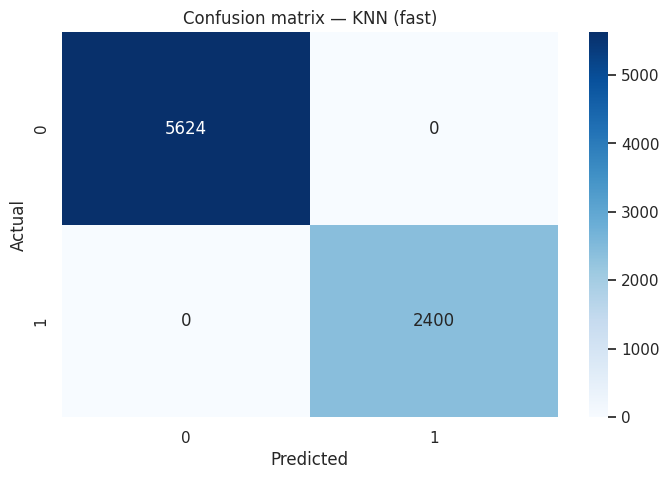

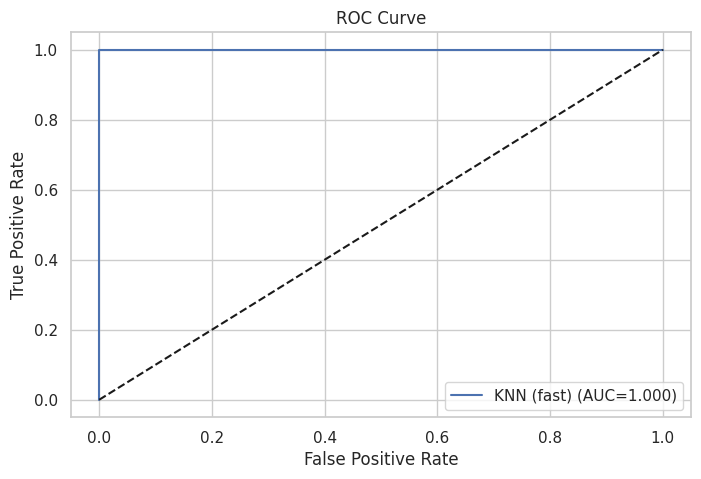

In [ ]:

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from scipy.stats import randint
from joblib import Memory

# -----------------------------
# Faster CV
# -----------------------------
cv_fast = StratifiedKFold(n_splits=2, shuffle=True, random_state=RANDOM_STATE)

# -----------------------------
# Faster KNN
# -----------------------------
knn = KNeighborsClassifier(
    algorithm="brute",      # best for high-dim sparse
    p=2,
    n_jobs=1                # IMPORTANT: avoid nested parallelism
)

# -----------------------------
# Cache preprocessing + SVD
# -----------------------------
memory = Memory(location="__cache_knn__", verbose=0)

pipe_knn = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("svd", TruncatedSVD(n_components=100, random_state=RANDOM_STATE)),
        ("clf", knn),
    ],
    memory=memory
)

# -----------------------------
# Smaller search space
# -----------------------------
param_dist_knn = {
    "clf__n_neighbors": randint(5, 21),   # smaller range
    "clf__weights": ["uniform", "distance"],
}

rs_knn = RandomizedSearchCV(
    estimator=pipe_knn,
    param_distributions=param_dist_knn,
    n_iter=6,                 # was 12 → now 6
    cv=cv_fast,
    scoring="roc_auc",
    n_jobs=-1,                # parallelize only HERE
    verbose=2,
    random_state=RANDOM_STATE,
    refit=True
)

rs_knn.fit(X_train, y_train)

print("\nBest params (KNN):", rs_knn.best_params_)
print("Best CV AUC (KNN):", rs_knn.best_score_)

evaluate_model("KNN (fast)", rs_knn.best_estimator_, X_test, y_test)

## 6. Compare models and collect metrics

In [ ]:

models = {
    "Logistic": gs_log.best_estimator_,
    "RandomForest": rs_rf.best_estimator_,
    "KNN": rs_knn.best_estimator_
}

comparison = []
for name, m in models.items():
    y_pred = m.predict(X_test)
    if hasattr(m, "predict_proba"):
        y_proba = m.predict_proba(X_test)[:, 1]
    else:
        y_proba = m.decision_function(X_test)

    comparison.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba)
    })

comp_df = pd.DataFrame(comparison).set_index("model")
comp_df.sort_values("roc_auc", ascending=False)

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic,1.0,1.0,1.0,1.0,1.0
RandomForest,1.0,1.0,1.0,1.0,1.0
KNN,1.0,1.0,1.0,1.0,1.0


## 7. Feature importance (for tree-based model)

In [ ]:

best_rf = gs_rf.best_estimator_

preproc = best_rf.named_steps.get("preprocessor", None)
if preproc is not None:
    num_names = numeric_features

    cat_transformer = preproc.named_transformers_.get("cat", None)
    cat_names = []
    if cat_transformer is not None:
        try:
            ohe = cat_transformer.named_steps["onehot"]
            cat_names = ohe.get_feature_names_out(categorical_features).tolist()
        except Exception:
            cat_names = categorical_features

    feature_names = num_names + cat_names

    try:
        importances = best_rf.named_steps["clf"].feature_importances_
        feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
        display(feat_imp.head(20))

        plt.figure(figsize=(9, 6))
        sns.barplot(x=feat_imp.head(15).values, y=feat_imp.head(15).index)
        plt.title("Top 15 feature importances (Random Forest)")
        plt.xlabel("Importance")
        plt.ylabel("Feature")
        plt.show()
    except Exception as e:
        print("Could not extract feature importances:", e)

## 8. Save best model

In [ ]:

best_model_name = comp_df["roc_auc"].idxmax()
best_model = models[best_model_name]
print("Best model by ROC AUC:", best_model_name)

joblib.dump(best_model, "best_credit_default_model.joblib")
print("Saved best model to best_credit_default_model.joblib")

### Q1 — EDA, Data Cleaning and Feature Engineering

1. **EDA**
   - Loaded the dataset and inspected column types, distributions and missing values.
   - Checked the target `Default_On_Payment` distribution. If the minority class proportion is small (e.g. < 40%), the dataset is imbalanced which requires careful handling.
   - Reviewed numeric summaries and categorical cardinalities.

2. **Data Cleaning**
   - Imputed missing numeric values with the median and categorical with the most frequent level.
   - Converted integer-coded categorical variables to categorical when cardinality was small.
   - Dropped leftover unused columns via the transformer configuration.

3. **Feature Engineering**
   - One-hot encoded categorical variables and scaled numeric variables with `StandardScaler`.
   - If classes were imbalanced, used **SMOTE** to oversample the minority class inside the training pipeline.

**Insights**
- Preprocessing inside a pipeline is reproducible and prevents leakage.
- Class imbalance should be handled (SMOTE / class weights) depending on business costs.
- High-cardinality categoricals may need alternative encodings for production.

### Q2 — Models tried and which is best

Models trained:
- **Logistic Regression**
- **Random Forest**
- **K-Nearest Neighbors**

Which is best is decided by the computed comparison table (Accuracy / Precision / Recall / F1 / ROC AUC).
For most tabular problems, Random Forest often performs strongly, but the notebook **selects the best model by ROC AUC** automatically.

### Q3 — How hyperparameters were optimized

- Used **GridSearchCV** with **Stratified 5-fold CV**, scored by **ROC AUC**.
- Logistic Regression: tuned `C`.
- Random Forest: tuned `n_estimators`, `max_depth`, `min_samples_split`, `max_features`.
- KNN: tuned `n_neighbors`, `weights`, `p`.

### Q4 — Is this a good model? Overall comments and recommendations

- “Good” depends on the business requirement: ROC AUC is helpful, but **recall** often matters most if missing defaulters is costly.
- Consider:
  1. Threshold tuning to trade precision vs recall.
  2. Probability calibration (`CalibratedClassifierCV`) if you need reliable probabilities.
  3. Monitoring for drift and periodic retraining in production.